In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
from scipy.spatial.distance import cdist


def sg_jacobian_projection(x: np.ndarray, y: np.ndarray, window_length: int = 151):
    """
    Aplica un filtro de Savitzky-Golay mediante proyección Jacobiana
    sobre una señal 1D, ajustando un polinomio cuadrático en ventanas deslizantes.

    Parámetros:
        x (np.ndarray): Vector de posiciones (eje x).
        y (np.ndarray): Vector de valores de la señal (eje y), del mismo tamaño que x.
        window_length (int): Longitud de la ventana (debe ser impar).

    Retorna:
        x_valid (np.ndarray): Puntos x donde la aproximación es válida.
        a_vals (np.ndarray): Coeficientes cuadráticos (curvatura).
        b_vals (np.ndarray): Coeficientes lineales (pendiente).
        c_vals (np.ndarray): Coeficientes constantes (offset).
    """
    assert window_length % 2 == 1, "window_length debe ser impar"
    assert len(x) == len(y), "x e y deben tener la misma longitud"

    dx = x[1] - x[0]
    half_win = window_length // 2
    x_local = np.arange(-half_win, half_win + 1) * dx

    # Matriz de diseño del Jacobiano
    J = np.vstack([x_local**2, x_local, np.ones_like(x_local)]).T
    JTJ_inv = np.linalg.inv(J.T @ J)
    J_pinv = JTJ_inv @ J.T

    # Aplicar proyección local
    a_vals, b_vals, c_vals = [], [], []
    for i in range(half_win, len(x) - half_win):
        y_window = y[i - half_win:i + half_win + 1]
        beta = J_pinv @ y_window
        a_vals.append(beta[0])
        b_vals.append(beta[1])
        c_vals.append(beta[2])

    x_valid = x[half_win: -half_win]
    return (
        np.asarray(x_valid),
        np.asarray(a_vals).ravel(),
        np.asarray(b_vals).ravel(),
        np.asarray(c_vals).ravel()
    )



def estimate_gaussian_params_from_parabola(a, b, c):
    a = np.asarray(a)
    b = np.asarray(b)
    c = np.asarray(c)
    x_v = -b / (2 * a)
    f_v = a * x_v**2 + b * x_v + c
    estimated_A = -f_v
    with np.errstate(divide='ignore', invalid='ignore'):
        estimated_sigma = np.sqrt(estimated_A / (2 * np.abs(a)))
    return estimated_A, estimated_sigma

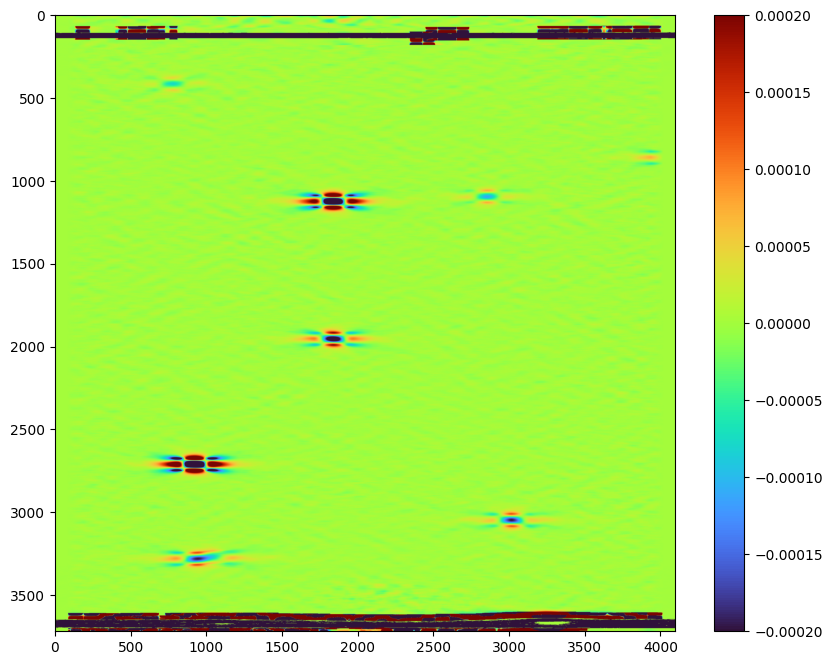

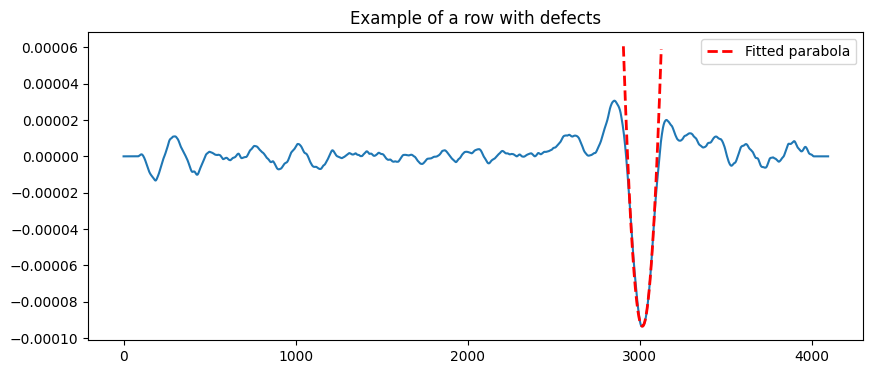

In [2]:
#%matplotlib qt

import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.signal import savgol_filter

defects = raw.read_img_raw(f"defectos_reales/picos/step_15_result_alg0.raw")
dist = raw.read_img_raw(f"defectos_reales/picos/step_15_orig.raw")
dist = savgol_filter(dist, 101, 2, axis=1)

# Configura la figura para mostrar la imagen del canal 0 y el gráfico de la primera fila
plt.close("all")
fig, (ax1) = plt.subplots(1, 1,figsize=(10, 8))  # Dos subgráficos, uno para la imagen y otro para el gráfico

# Muestra la imagen del canal 0
im = ax1.imshow(defects, aspect='auto',vmin=-0.0002, vmax=.0002, cmap='turbo')
cbar = fig.colorbar(im, ax=ax1)


plt.figure(figsize=(10, 4))
plt.plot(defects[3066, :])
plt.title("Example of a row with defects")

# Get coefficients around x=778
x_local = np.arange(len(defects[3066, :]))
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x_local, defects[3066, :], window_length=31)

# Find index closest to x=778
idx = np.abs(x_valid - 3015).argmin()

# Plot parabola around x=778
x_parab = np.linspace(3015-110, 3015+110, 200)
y_parab = a_vals[idx]*(x_parab - 3015)**2 + b_vals[idx]*(x_parab - 3015) + c_vals[idx]
plt.plot(x_parab, y_parab, 'r--', linewidth=2, label='Fitted parabola')
plt.legend()

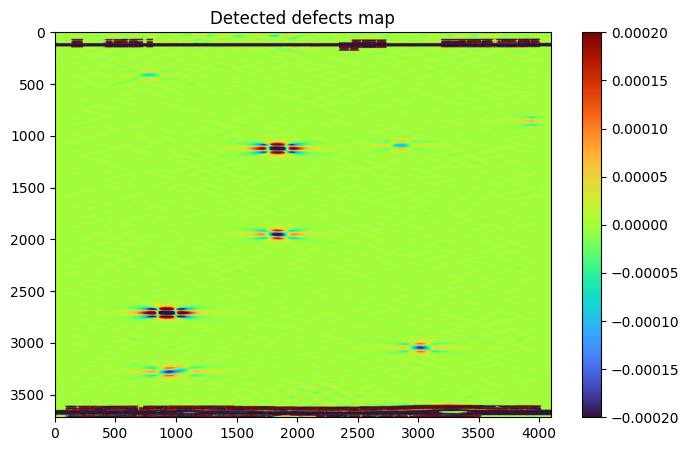

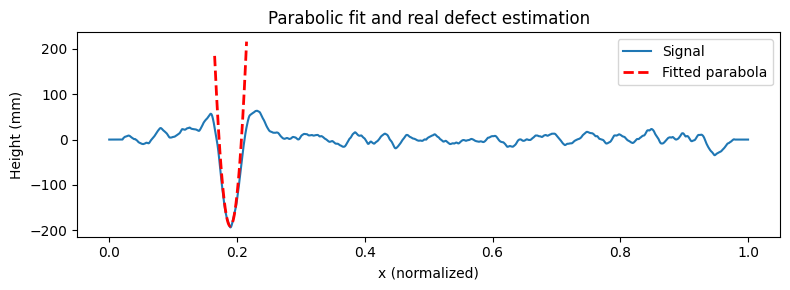

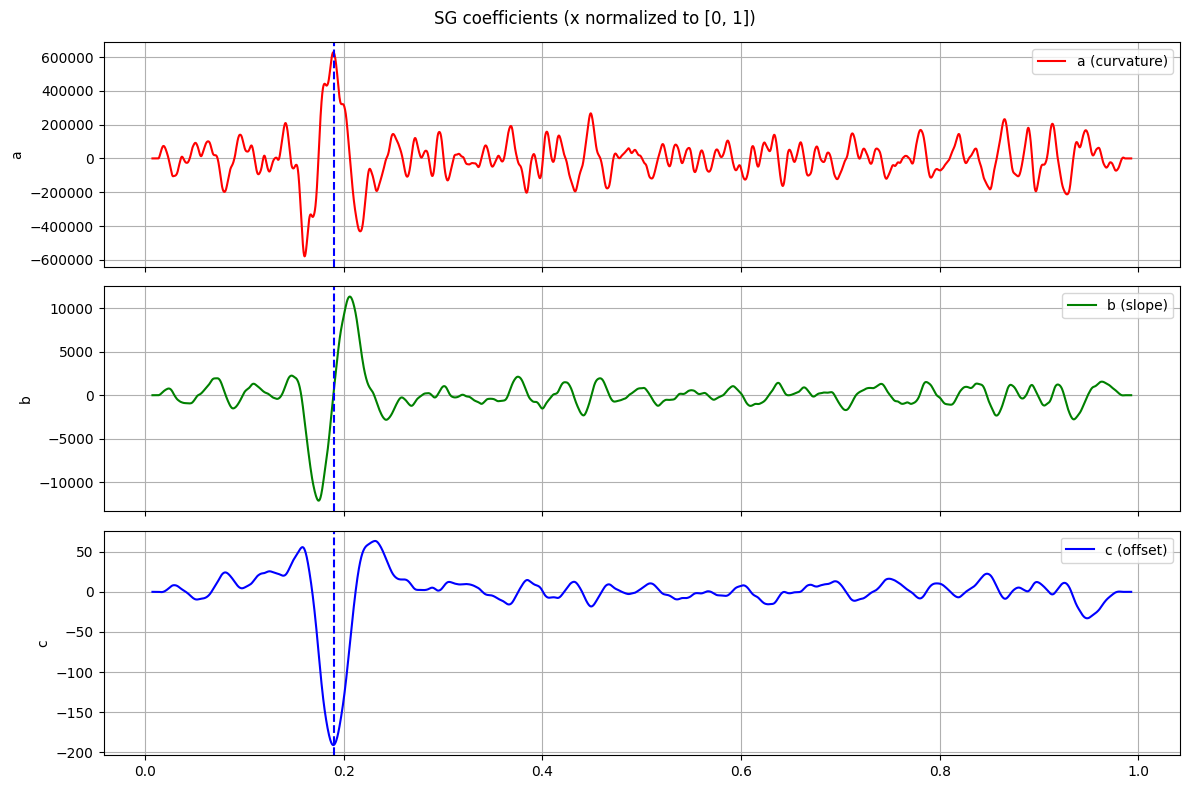

In [4]:
# Librerías
import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.signal import savgol_filter
from numpy.polynomial.polynomial import polyfit


# Parámetros de regresión obtenidos previamente (ya invertidos)
b0_A, b1_A = 0.027781, -0.01049       # profundidad
b0_sigma, b1_sigma = -1.71341, 2008.40866   # anchura

# Cargar y preprocesar imagen
defects = raw.read_img_raw("defectos_reales/picos/step_15_result_alg0.raw")

# Preprocesar señal de distancia original (suavizado opcional)
dist = raw.read_img_raw("defectos_reales/picos/step_15_orig.raw")
dist = savgol_filter(dist, 101, 2, axis=1) 

# Mostrar imagen de defectos
plt.close("all")
fig, ax1 = plt.subplots(1, 1, figsize=(8, 5))
im = ax1.imshow(defects, aspect='auto', vmin=-0.0002, vmax=0.0002, cmap='turbo')
cbar = fig.colorbar(im, ax=ax1)
ax1.set_title("Detected defects map")

defects = defects * 2.5e6  # pasa a unidades físicas


# Línea para analizar
row = 411
n_points = len(defects[row, :])
x_local = np.linspace(0, 1, n_points)  # ¡normalizado!
x_centro = x_local[778]

# Proyección SG con x escalado
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x_local, defects[row, :], window_length=61)

# Estimación de la parábola en la posición más cercana a x_centro
idx = np.abs(x_valid - x_centro).argmin()
a, b, c = a_vals[idx], b_vals[idx], c_vals[idx]

# Estimación SG → Gaussiano
A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a, b, c)

# Corrección según regresión
real_depth = b0_A + b1_A * A_hat
real_sigma = b0_sigma + b1_sigma * sigma_hat

# Visualización del ajuste
x_parab = np.linspace(x_centro - 0.025, x_centro + 0.025, 200)
y_parab = a * (x_parab - x_centro)**2 + b * (x_parab - x_centro) + c

plt.figure(figsize=(8, 3))
plt.plot(x_local, defects[row, :], label="Signal")
plt.plot(x_parab, y_parab, 'r--', linewidth=2,
         label='Fitted parabola')
      #    label=f'Fitted parabola:\n$y = {a:.2e}(x - x_0)^2 + {b:.2e}(x - x_0) + {c:.2e}$\n'
      #          f'Depth ≈ {real_depth:.3f} mm\nWidth ≈ {real_sigma:.3f} mm')
plt.title("Parabolic fit and real defect estimation")
plt.xlabel("x (normalized)")
plt.ylabel("Height (mm)")
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Coeficientes a, b, c a lo largo de la línea
# ===============================
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(x_valid, a_vals, label="a (curvature)", color='red')
axs[0].axvline(x_centro, color='blue', linestyle='--')
axs[0].set_ylabel("a")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x_valid, b_vals, label="b (slope)", color='green')
axs[1].axvline(x_centro, color='blue', linestyle='--')
axs[1].set_ylabel("b")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(x_valid, c_vals, label="c (offset)", color='blue')
axs[2].axvline(x_centro, color='blue', linestyle='--')
axs[2].set_ylabel("c")
axs[2].legend()
axs[2].grid(True)

plt.suptitle("SG coefficients (x normalized to [0, 1])")
plt.tight_layout()
plt.show()



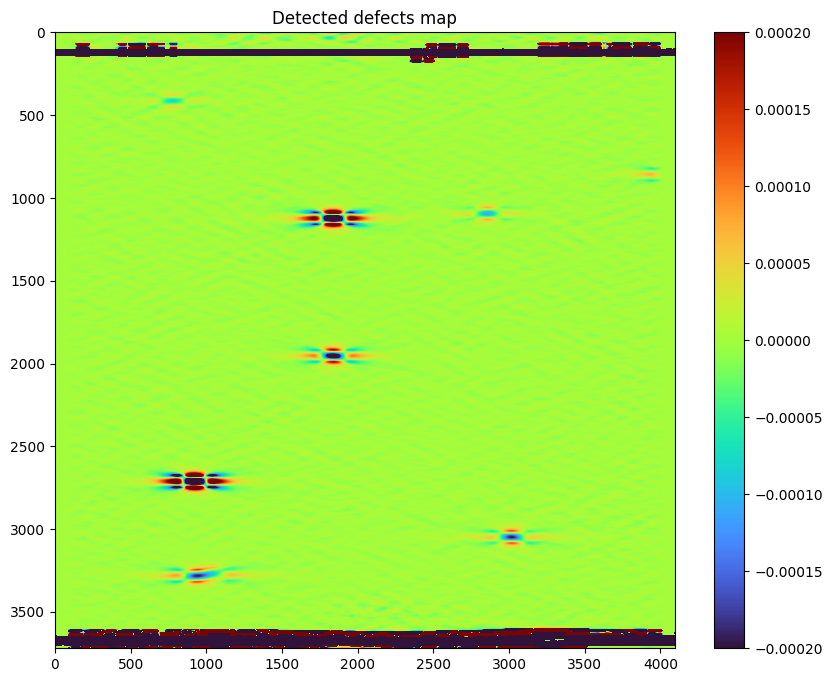

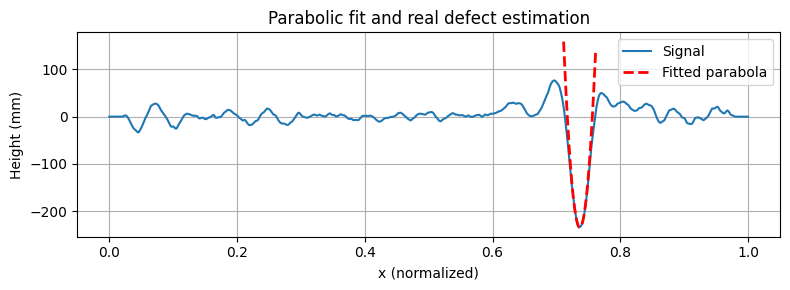

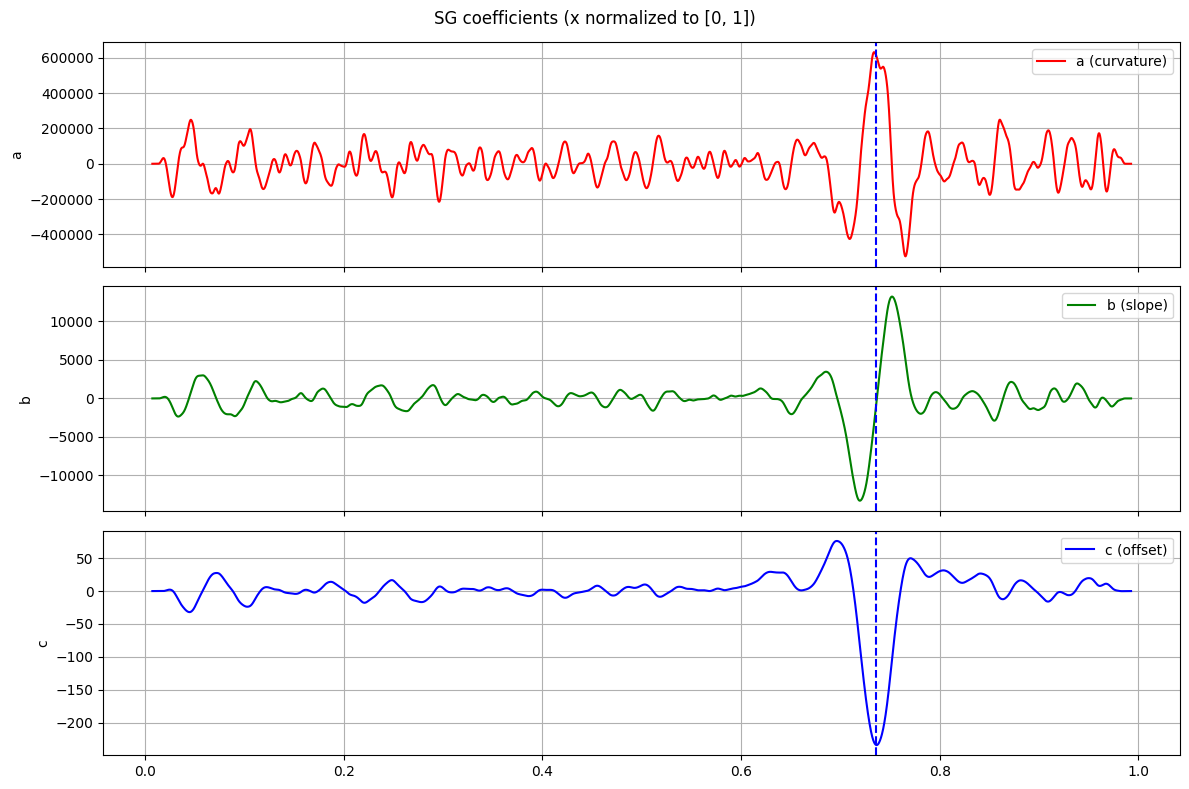

In [ ]:
# Librerías
import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.signal import savgol_filter
from numpy.polynomial.polynomial import polyfit


# Parámetros de regresión obtenidos previamente (ya invertidos)
b0_A, b1_A = 0.027781, -0.01049       # profundidad
b0_sigma, b1_sigma = -1.71341, 2008.40866   # anchura

# Cargar y preprocesar imagen
defects = raw.read_img_raw("defectos_reales/picos/step_15_result_alg0.raw")

# Preprocesar señal de distancia original (suavizado opcional)
dist = raw.read_img_raw("defectos_reales/picos/step_15_orig.raw")
dist = savgol_filter(dist, 101, 2, axis=1) 

# Mostrar imagen de defectos
plt.close("all")
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))
im = ax1.imshow(defects, aspect='auto', vmin=-0.0002, vmax=0.0002, cmap='turbo')
cbar = fig.colorbar(im, ax=ax1)
ax1.set_title("Detected defects map")

defects = defects * 2.5e6  # pasa a unidades físicas


# Línea para analizar
row = 3066
n_points = len(defects[row, :])
x_local = np.linspace(0, 1, n_points)  # ¡normalizado!
x_centro = x_local[3015]

# Proyección SG con x escalado
x_valid, a_vals, b_vals, c_vals = sg_jacobian_projection(x_local, defects[row, :], window_length=61)

# Estimación de la parábola en la posición más cercana a x_centro
idx = np.abs(x_valid - x_centro).argmin()
a, b, c = a_vals[idx], b_vals[idx], c_vals[idx]

# Estimación SG → Gaussiano
A_hat, sigma_hat = estimate_gaussian_params_from_parabola(a, b, c)

# Corrección según regresión
real_depth = b0_A + b1_A * A_hat
real_sigma = b0_sigma + b1_sigma * sigma_hat

# Visualización del ajuste
x_parab = np.linspace(x_centro - 0.025, x_centro + 0.025, 200)
y_parab = a * (x_parab - x_centro)**2 + b * (x_parab - x_centro) + c

plt.figure(figsize=(8, 3))
plt.plot(x_local, defects[row, :], label="Signal")
plt.plot(x_parab, y_parab, 'r--', linewidth=2,
         label='Fitted parabola')
      #    label=f'Fitted parabola:\n$y = {a:.2e}(x - x_0)^2 + {b:.2e}(x - x_0) + {c:.2e}$\n'
      #          f'Depth ≈ {real_depth:.3f} mm\nWidth ≈ {real_sigma:.3f} mm')
plt.title("Parabolic fit and real defect estimation")
plt.xlabel("x (normalized)")
plt.ylabel("Height (mm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ===============================
# Coeficientes a, b, c a lo largo de la línea
# ===============================
fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axs[0].plot(x_valid, a_vals, label="a (curvature)", color='red')
axs[0].axvline(x_centro, color='blue', linestyle='--')
axs[0].set_ylabel("a")
axs[0].legend()
axs[0].grid(True)

axs[1].plot(x_valid, b_vals, label="b (slope)", color='green')
axs[1].axvline(x_centro, color='blue', linestyle='--')
axs[1].set_ylabel("b")
axs[1].legend()
axs[1].grid(True)

axs[2].plot(x_valid, c_vals, label="c (offset)", color='blue')
axs[2].axvline(x_centro, color='blue', linestyle='--')
axs[2].set_ylabel("c")
axs[2].legend()
axs[2].grid(True)

plt.suptitle("SG coefficients (x normalized to [0, 1])")
plt.tight_layout()
plt.show()



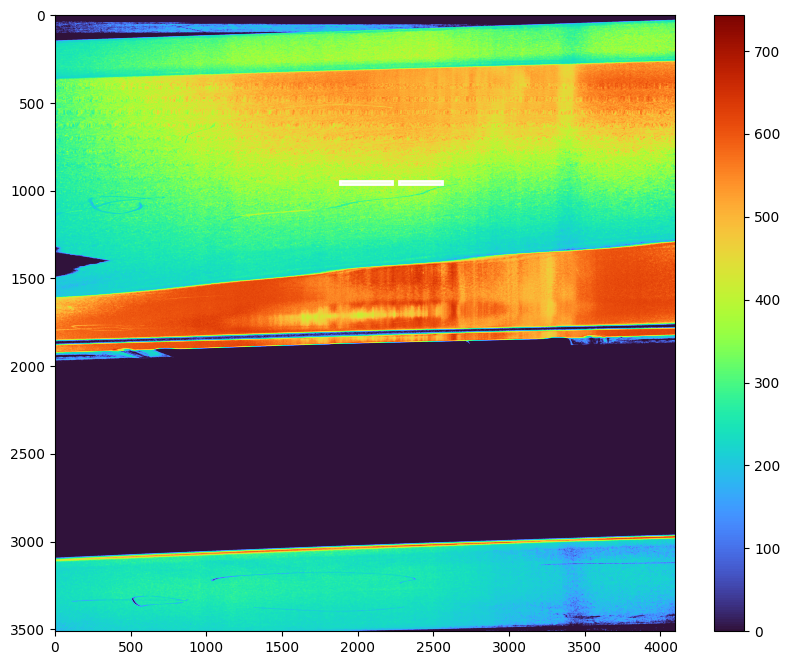

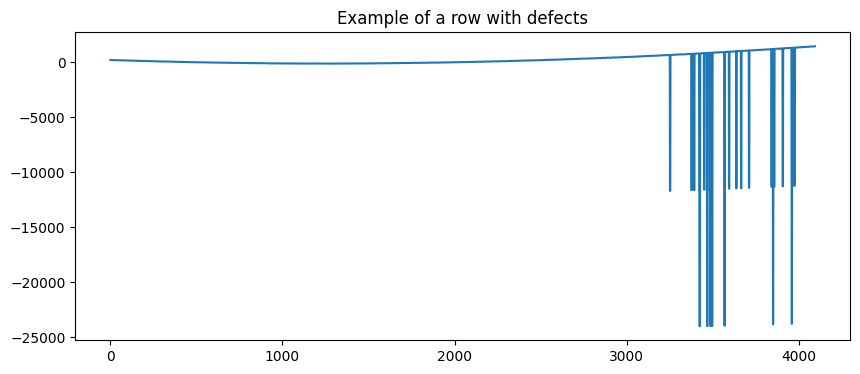

In [ ]:
#%matplotlib qt

import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from matplotlib.patches import Rectangle
from scipy.signal import savgol_filter

# Leer imágenes
defects = raw.read_img_raw(f"defectos_reales/2023-05-26_12-13-25_bollo_suciedad/2G6827105_m05_6_05_26/scans/scanS5_lum.raw")
dist = raw.read_img_raw(f"defectos_reales/2023-05-26_12-13-25_bollo_suciedad/2G6827105_m05_6_05_26/scans/scanS5_range.raw")

# Obtener dimensiones de la imagen
img_height, img_width = defects.shape[:2]

# Bounding boxes (datos normalizados)
bboxes = [
    {"x_position": 0.55481, "y_position": 0.268935, "x_size": 0.0695801, "y_size": 0.00432783},
    {"x_position": 0.459473, "y_position": 0.268793, "x_size": 0.0849609, "y_size": 0.00486881}
]


# Mostrar imagen con bounding boxes
plt.close("all")
fig, ax1 = plt.subplots(1, 1, figsize=(10, 8))

im = ax1.imshow(defects, aspect='auto', cmap='turbo')
fig.colorbar(im, ax=ax1)

# Dibujar los bounding boxes
for bbox in bboxes:
    rect = Rectangle(
        (bbox["x_position"] * img_width, bbox["y_position"] * img_height),
        bbox["x_size"] * img_width,
        bbox["y_size"] * img_height,
        linewidth=2, edgecolor='white', facecolor='none'
    )
    ax1.add_patch(rect)

# Segunda gráfica (señal detrendida y suavizada)
plt.figure(figsize=(10, 4))

def detrend(y):
    x = np.arange(len(y))
    y_flat = y.ravel()
    z = np.polyfit(x, y_flat, 2)
    p = np.poly1d(z)
    return y_flat - p(x)

plt.plot(savgol_filter(detrend(dist[3287, :]), 3, 1))
plt.title("Example of a row with defects")

plt.show()
